# Modeling study — starter
Fits the four python surrogates on one shared SLHD design and scores them against the analytic
ground truth over the WHOLE domain (not just near an optimum — this is a modeling study).
See README.md for full context: models, metrics, suggested experiment axes.

In [6]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, matplotlib.pyplot as plt
from utils import problems as P, doe_cache
from utils.models import MODELS
# MODELS OF RECORD: python GPs + the MATLAB LVGP engines (via the mfit/mpredict bridge).
# The python LVGP ports (lvgp_native / heter_lvgp_native) exist as reference only -- swap
# them in here if you need fast iteration without MATLAB.
USE_MODELS = ["separate_gp", "categorical_kernel", "standard_LVGP", "heter_LVGP"]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [7]:
PROBLEM = "branin_hetero"      # or "rastrigin_6d"
SEED    = 1
N_REP   = 10                    # replicates per design point
NGRID   = 200                   # ground-truth evaluation grid (per level, along x1 for d>1 slices)

## Data: shared SLHD design with replicates

In [8]:
spec = P.get(PROBLEM)
doe_cache.ensure(PROBLEM, SEED, N_REP)
ds = doe_cache.load(PROBLEM, SEED, N_REP)
X, Y, V = ds["X_sample"], ds["Y_sample"], ds["Var_sample"]
data = {int(lv): dict(X=X[X[:, spec.d].astype(int) == lv, :spec.d],
                      y_mean=Y[X[:, spec.d].astype(int) == lv],
                      y_var=V[X[:, spec.d].astype(int) == lv]) for lv in spec.levels}
print(f"{PROBLEM}: d={spec.d}, levels={spec.n_levels}, n_train={len(Y)} (n_init={spec.n_init})")

branin_hetero: d=1, levels=5, n_train=10 (n_init=10)


## Fit all four models + whole-domain metrics vs ground truth
Evaluation grid: dense in x for d=1; for d>1 swap in a Sobol sample of the box (see README §metrics).

In [9]:
import pandas as pd
xs = np.linspace(spec.lb, spec.ub, NGRID).reshape(-1, 1) if spec.d == 1 else None
if xs is None:                                   # d>1: Sobol sample of the box
    from scipy.stats import qmc
    b = np.atleast_2d(np.asarray(spec.bounds, float))
    xs = b[:, 0] + qmc.Sobol(spec.d, scramble=False).random(512) * (b[:, 1] - b[:, 0])
rows, fitted = [], {}
for name in USE_MODELS:
    mdl = MODELS[name].cls.fit(data, needs_r=True, bounds=spec.bounds)
    fitted[name] = mdl
    err, ss, rr, tt, ftall = [], [], [], [], []
    for lv in spec.levels:
        ft  = np.ravel(spec.f_true_level(xs, lv))
        st2 = np.ravel(spec.sigma_level(xs, lv)) ** 2
        mu, s = mdl.mean_std(lv, xs); r = np.ravel(mdl.r(lv, xs))
        err.append(mu - ft); ss.append(np.maximum(s, 1e-9)); rr.append(r); tt.append(st2); ftall.append(ft)
    e, s_, r_, t_ = map(np.concatenate, (err, ss, rr, tt))
    fstd = np.std(np.concatenate(ftall))
    rows.append(dict(model=name, MAE=np.mean(np.abs(e)), RRMSE=np.sqrt(np.mean(e**2))/fstd,
                     cov90=np.mean(np.abs(e) <= 1.645*s_),
                     nMAE=(np.nanmean(np.abs(r_-t_))/t_.mean()) if np.isfinite(r_).any() else np.nan))
pd.DataFrame(rows).set_index("model").round(3)

,MAE,RRMSE,cov90,nMAE
model,,,,
separate_gp,26.169,0.763,0.668,0.521
categorical_kernel,24.537,0.683,0.942,0.521
standard_LVGP,24.715,0.710,0.330,NaN
heter_LVGP,43.369,1.009,0.354,0.407


## Visual check (d=1): true f ± 2σ per level, with each model's fit
One row per model: posterior mean ± 2·epistemic std against the true curve and noise band.

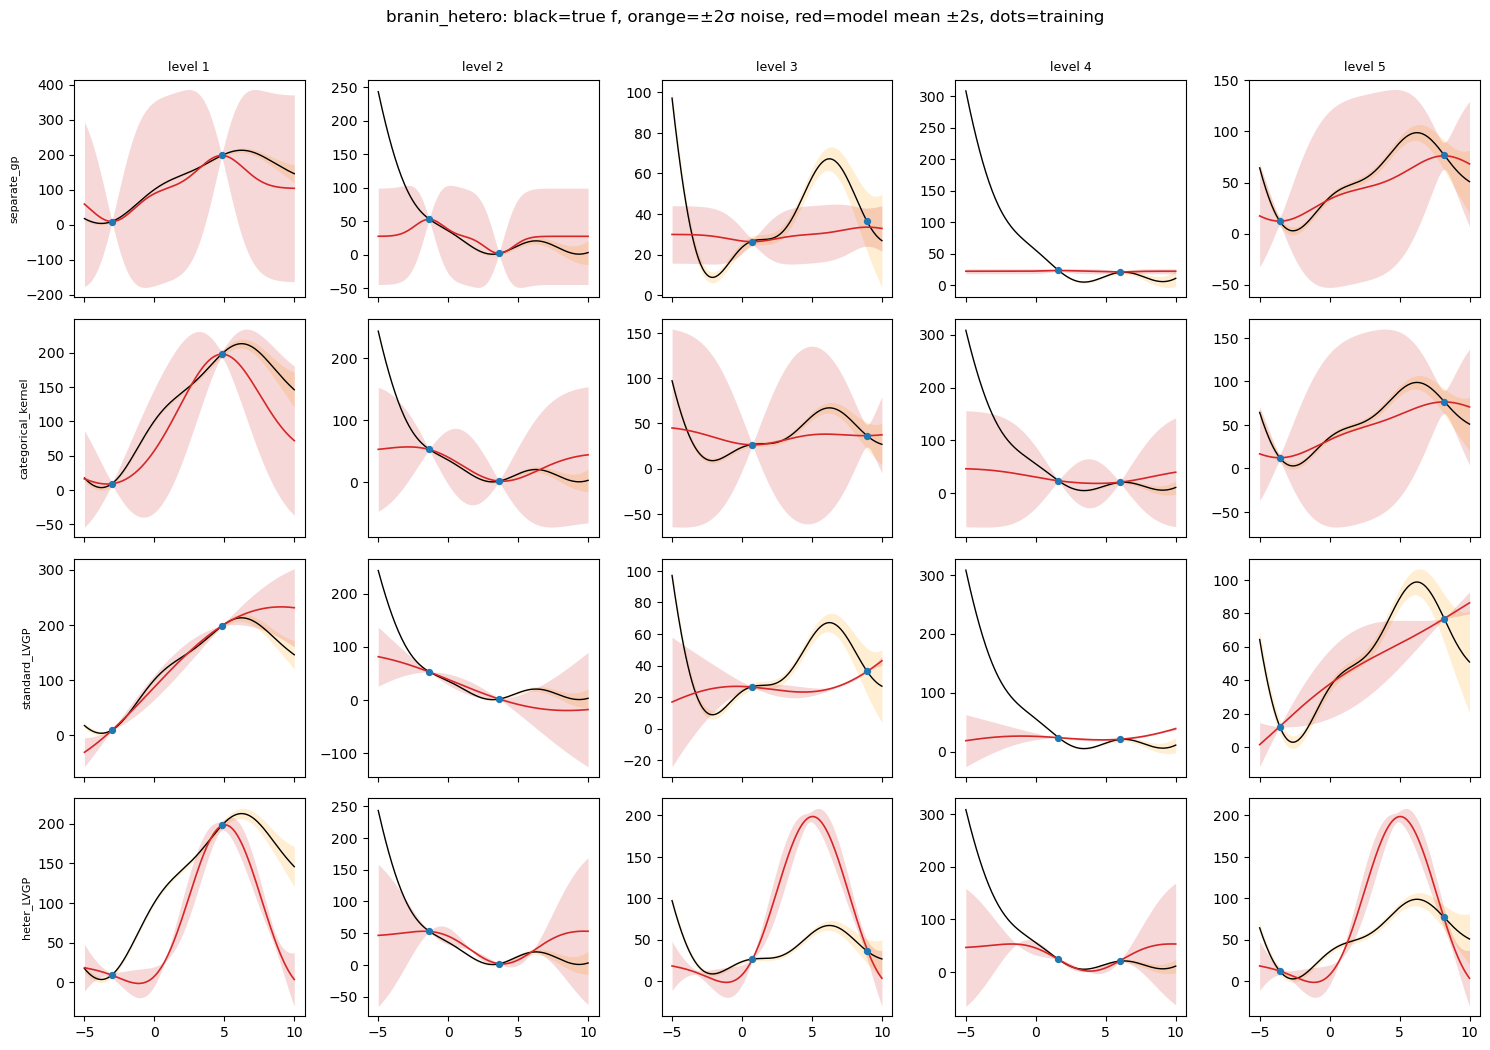

In [10]:
if spec.d == 1:
    fig, axes = plt.subplots(len(USE_MODELS), spec.n_levels, figsize=(3.0*spec.n_levels, 2.6*len(USE_MODELS)),
                             sharex=True, squeeze=False)
    for i, name in enumerate(USE_MODELS):
        mdl = fitted[name]
        for j, lv in enumerate(spec.levels):
            ax = axes[i, j]
            ft = np.ravel(spec.f_true_level(xs, lv)); sg = np.ravel(spec.sigma_level(xs, lv))
            mu, s = mdl.mean_std(lv, xs)
            ax.fill_between(xs.ravel(), ft-2*sg, ft+2*sg, color="orange", alpha=0.18, lw=0)
            ax.plot(xs.ravel(), ft, "k-", lw=1)
            ax.plot(xs.ravel(), mu, "C3-", lw=1.2)
            ax.fill_between(xs.ravel(), mu-2*s, mu+2*s, color="C3", alpha=0.18, lw=0)
            d_lv = data.get(lv)
            if d_lv is not None and len(d_lv["y_mean"]):
                ax.scatter(np.ravel(d_lv["X"]), d_lv["y_mean"], s=18, c="C0", zorder=5)
            if i == 0: ax.set_title(f"level {lv}", fontsize=9)
            if j == 0: ax.set_ylabel(name, fontsize=8)
    fig.suptitle(f"{PROBLEM}: black=true f, orange=±2σ noise, red=model mean ±2s, dots=training", y=1.005)
    plt.tight_layout(); plt.show()

## Next experiments (see README)
1. **Sample-size sweep** — learning curves n_train vs each metric, ≥20 seeds.
2. **Replicate sweep** — n_rep ∈ {1,3,10,30} at fixed total budget.
3. **Calibration curves** — coverage vs nominal τ.
4. **Latent recovery** — fitted z-distances vs true level-curve distances (Spearman ρ).
5. **Noise-surface recovery** — r(x,ℓ) vs σ²(x,ℓ).